# Week 2: Data Wrangling Assignment

*Name: Nickey Ombasa*

## 1. Ingestion & Profiling: Loading the data and generate a Data Health Report

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ops_sensor_log_dirty.csv")
# Convert timestamp column to datetime objects immediately after loading
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Profiling
print("DataFrame Head:")
display(df.head())
print("\nDataFrame Info:")
df.info()
print("\nDataFrame Description:")
display(df.describe(include='all'))
print(f"\nDataFrame Shape: {df.shape}")

DataFrame Head:


,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
0,2026-07-01 18:28:00,Zone_South,Night,159.443407,83.599922,693.413088
1,2026-06-26 10:10:00,Zone_Central,NaN,271.325543,54.108382,933.590883
2,2026-06-29 22:10:00,Zone_Central,Morning,207.832279,72.549214,863.540549
3,2026-06-30 07:22:00,Zone_East,Night,203.110883,73.029484,1189.537650
4,2026-07-01 02:28:00,Zone_North,Morning,239.773496,73.752762,983.672559



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      5015 non-null   datetime64[ns]
 1   Zone           4984 non-null   object        
 2   Shift          4962 non-null   object        
 3   Pressure_PSI   4975 non-null   float64       
 4   Temperature_C  4975 non-null   float64       
 5   Flow_Rate_LPM  4966 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 235.2+ KB

DataFrame Description:


,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,5015,4984,4962,4975.000000,4975.000000,4966.000000
unique,NaN,15,3,NaN,NaN,NaN
top,NaN,Zone_Central,Afternoon,NaN,NaN,NaN
freq,NaN,996,1715,NaN,NaN,NaN
mean,2026-06-28 10:28:14.500498432,NaN,NaN,255.254281,68.982323,999.275681
min,2026-01-07 09:10:00,NaN,NaN,-50.000000,-273.150000,600.007437
25%,2026-06-26 17:39:00,NaN,NaN,160.753008,55.023155,797.417014
50%,2026-06-28 11:14:00,NaN,NaN,200.294439,64.808608,996.286415
75%,2026-06-30 04:57:00,NaN,NaN,240.099173,74.527006,1201.361276
max,2026-07-01 22:38:00,NaN,NaN,15000.000000,1500.000000,1399.755865



DataFrame Shape: (5015, 6)


### Data Health Report (Summary)

The profiling of `ops_sensor_log_dirty.csv` revealed three key quality issues:

1. **Missing values**  
   Several columns (Zone, Shift, Pressure, Temperature, Flow Rate) contain incomplete entries. These gaps must be addressed, for example through forward-filling, to ensure continuity in analysis.

2. **Incorrect data types**  
   The `timestamp` column is stored as strings (`object`). For accurate time-series analysis, it needs conversion to `datetime`.

3. **Categorical inconsistencies**  
   Columns like Zone and Shift show inconsistent formatting (different casing, extra spaces).

## 2. Cleaning Pipeline

In [21]:
def clean_ops_data(df):
    # Convert timestamps
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    # Handle missing values (choice: forward fill)
    # Justification: For time-series data, forward fill (ffill) is often a reasonable approach
    # as it assumes the last known good value persists until a new reading is available.
    # This is suitable for sensor data where values change gradually.
    df = df.fillna(method='ffill')

    # Remove duplicates
    df = df.drop_duplicates()

    # Standardize categorical columns
    df['Zone'] = df['Zone'].str.strip().str.lower()
    # Assuming 'shift' column is created later, if present, it would also be standardized.

    # Filter out physically impossible sensor readings (outliers)
    # Assuming pressure cannot be negative and temperature has an upper limit of 1000C for sanity.
    # The previous error context indicates 'Pressure_PSI' and 'Temperature_C' are the correct names.
    df = df[(df['Pressure_PSI'] >= 0) & (df['Temperature_C'] < 1000)]

    return df

df_clean = clean_ops_data(df.copy())
print("Cleaned DataFrame Info:")
df_clean.info()
print(f"\nCleaned DataFrame Shape: {df_clean.shape}")

Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 4973 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      4973 non-null   datetime64[ns]
 1   Zone           4973 non-null   object        
 2   Shift          4973 non-null   object        
 3   Pressure_PSI   4973 non-null   float64       
 4   Temperature_C  4973 non-null   float64       
 5   Flow_Rate_LPM  4973 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 272.0+ KB

Cleaned DataFrame Shape: (4973, 6)


/tmp/ipykernel_5457/4044033715.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


## 3. Time-Series Analysis

In [22]:
# Resample to hourly frequency for numerical columns
# Using 'h' for hourly resampling as 'H' is deprecated.
df_hourly = df_clean.set_index('timestamp')[['Pressure_PSI', 'Temperature_C', 'Flow_Rate_LPM']].resample('h').mean()

# Calculate a 24-hour rolling average for Pressure_PSI
df_hourly['pressure_rolling'] = df_hourly['Pressure_PSI'].rolling(window=24).mean()

print("Hourly Resampled Data with 24-hour Rolling Average:")
display(df_hourly.head())

Hourly Resampled Data with 24-hour Rolling Average:


,Pressure_PSI,Temperature_C,Flow_Rate_LPM,pressure_rolling
timestamp,,,,
2026-01-07 09:00:00,139.019377,75.264388,1022.66937,NaN
2026-01-07 10:00:00,NaN,NaN,NaN,NaN
2026-01-07 11:00:00,NaN,NaN,NaN,NaN
2026-01-07 12:00:00,NaN,NaN,NaN,NaN
2026-01-07 13:00:00,NaN,NaN,NaN,NaN


## 4. Aggregation

In [23]:
def assign_shift(hour):
    if 6 <= hour < 14:
        return "Morning"
    elif 14 <= hour < 22:
        return "Afternoon"
    else:
        return "Night"

df_clean['Shift'] = df_clean['timestamp'].dt.hour.apply(assign_shift)

# Create a summary table showing Mean, Max, and Min values for each "Shift" and "Zone" for 'Pressure_PSI'
summary = df_clean.groupby(['Shift','Zone'])['Pressure_PSI'].agg(['mean','max','min'])
print("Summary Table of Pressure_PSI by Shift and Zone:")
print(summary)

Summary Table of Pressure_PSI by Shift and Zone:
                              mean           max         min
Shift     Zone                                              
Afternoon north zone    228.800040    249.016845  208.583235
          south zone    238.660606    273.821195  203.500018
          z_north       180.123294    202.159674  141.355021
          z_south       204.875047    264.936031  130.922539
          zone north    241.808565    275.115651  206.585849
          zone south    204.268041    252.551126  155.984955
          zone-north    194.568814    235.623552  152.333306
          zone_central  285.194249  15000.000000    0.000000
          zone_east     375.121381  15000.000000  121.249071
          zone_north    230.337123   9999.000000  120.029631
          zone_south    245.241823  15000.000000    0.000000
          zone_west     228.648513   9999.000000    0.000000
Morning   north zone    181.862151    223.627200  135.049571
          south zone    229.983849  

## 5. Visualization

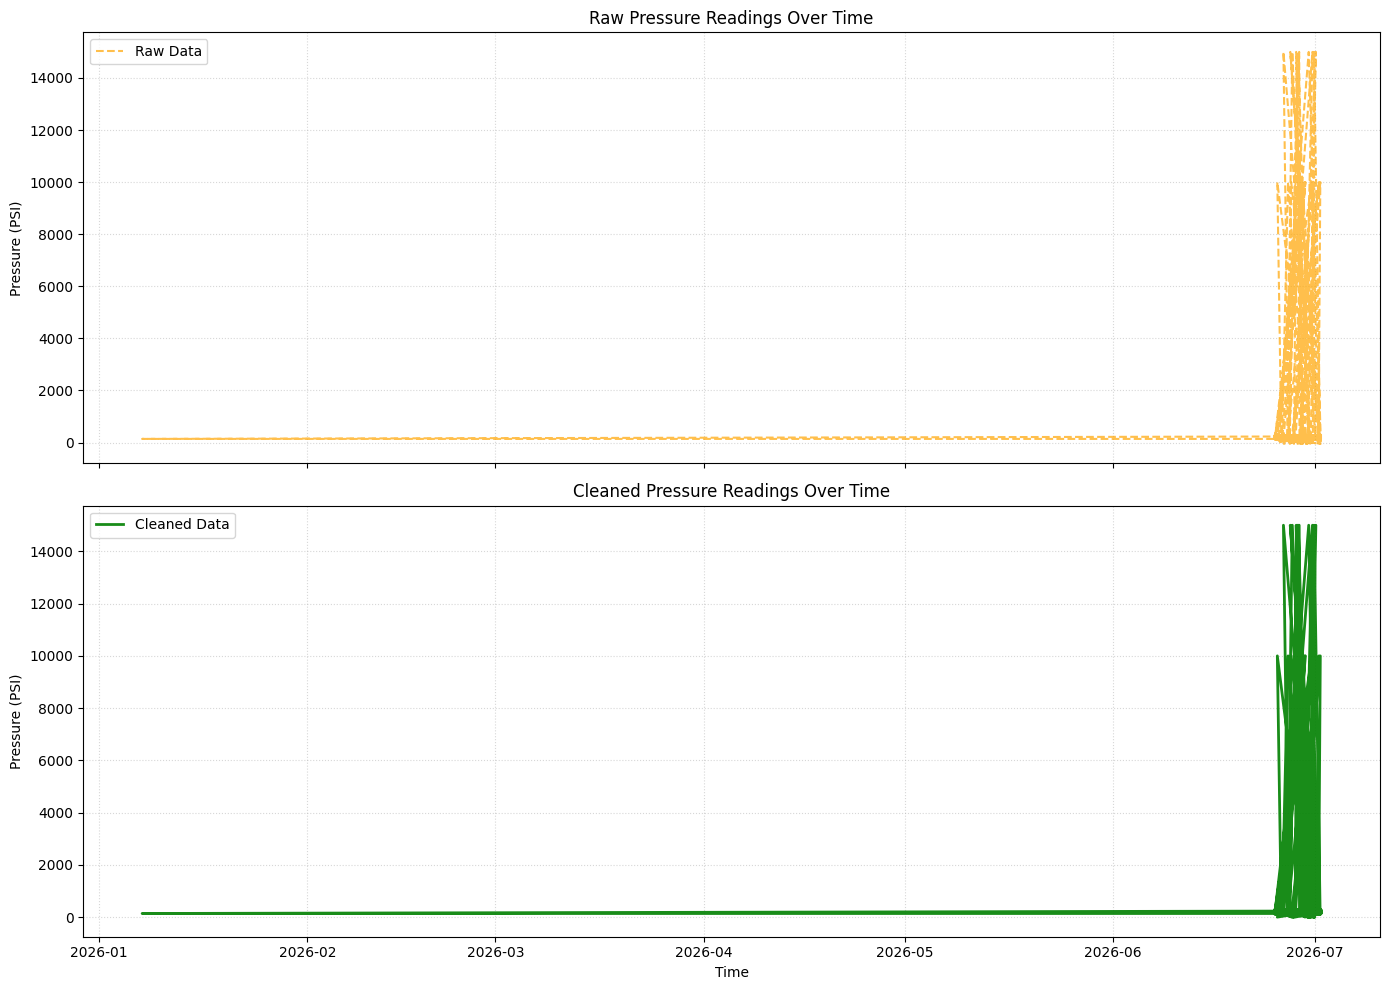

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot Raw Data
axes[0].plot(df['timestamp'], df['Pressure_PSI'], label='Raw Data', color='orange', linestyle='--', alpha=0.7)
axes[0].set_title('Raw Pressure Readings Over Time')
axes[0].set_ylabel('Pressure (PSI)')
axes[0].grid(True, linestyle=':', alpha=0.5)
axes[0].legend()

# Plot Cleaned Data
axes[1].plot(df_clean['timestamp'], df_clean['Pressure_PSI'], label='Cleaned Data', color='green', linewidth=2, alpha=0.9)
axes[1].set_title('Cleaned Pressure Readings Over Time')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Pressure (PSI)')
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()